## SDP Solve-Time Benchmark

Benchmark to see how SDP solve time scales with the **basis size**.
We sample random k-subsets of the NPA adding set (level `end_level` minus level `start_level`), solve the SDP, and plot timing statistics (mean ± std and min–max).

In [1]:
import os
import platform
import sys

print("sys.executable:", sys.executable)
print("sys.prefix:", sys.prefix)
print("platform:", platform.platform())
print("os.name:", os.name)

sys.executable: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/.venv/bin/python
sys.prefix: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/.venv
platform: Linux-5.14.0-611.27.1.el9_7.x86_64-x86_64-with-glibc2.34
os.name: posix


In [ ]:
# Benchmark a fixed total basis size L across many N
# This chooses k(N) so that basis_size = len(starting_set(N)) + k(N) == fixed_basis_size.
from pathlib import Path
import numpy as np
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

fixed_basis_size = 20
out_basis_npz = Path("spins_sdp/results/sdp_benchmark_byBasisSize.npz")
for L in [20, 40, 61, 80, 100]:
    out_L = sb.compute_fixed_basis_size_across_N_and_save(
        N_values=np.arange(4, 20),
        fixed_basis_size=L,
        model_name="heisenberg",
        model_params={},
        start_level=1,
        end_level=4,
        num_trials=3,
        mosek_tol=1e-9,
        out_root=Path("spins_sdp/results"),
        out_npz=out_basis_npz,
        verbose=False,
    )
    print(out_L)


In [ ]:
# Plot total solve time vs N for one or more fixed basis sizes L (mean ± std)
from pathlib import Path
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

npz_path = Path("spins_sdp/results/sdp_benchmark_byBasisSize.npz")

Ls_to_plot = [20,40,61,80,100]

sb.plot_total_time_vs_N_for_fixed_basis_sizes(
    npz_path,
    Ls_to_plot,
    yscale="log",
    title="SDP benchmark: total time vs N (fixed basis size L)",
)


In [ ]:
# Benchmark fixed N while sweeping total basis size L (by translating L -> k for that N)
from pathlib import Path
import numpy as np
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

N_fixed = 10  # fixed system size
basis_sizes = list(range(100, 121, 5))  # desired total basis sizes
out_npz_fixedN = Path("spins_sdp/results/sdp_benchmark_fixedN_byBasisSize.npz")

for N in [N_fixed]:
    out_path = sb.compute_fixed_N_across_basis_size_and_save(
        N=N,
        basis_sizes=list([50,100,200]), #basis_sizes,
        model_name="heisenberg",
        model_params={},
        start_level=1,
        end_level=4,
        num_trials=1,
        mosek_tol=1e-9,
        out_root=Path("spins_sdp/results"),
        out_npz=out_npz_fixedN,
        verbose=True,
    )
    print(out_path)


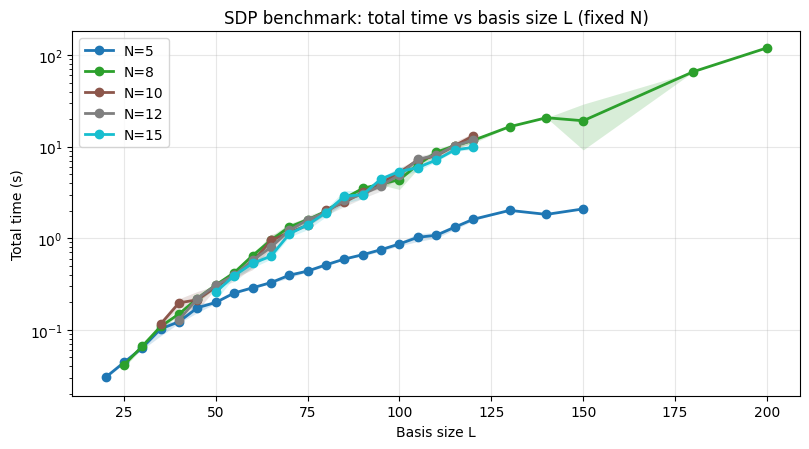

(<Figure size 820x460 with 1 Axes>,
 <Axes: title={'center': 'SDP benchmark: total time vs basis size L (fixed N)'}, xlabel='Basis size L', ylabel='Total time (s)'>)

In [4]:
# Plot total solve time vs basis size L for this fixed N (mean ± std)
from pathlib import Path
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

npz_path = Path("spins_sdp/results/sdp_benchmark_fixedN_byBasisSize.npz")

sb.plot_total_time_vs_basis_size_for_fixed_N(
    npz_path,
    [5, 8, 10, 12, 15],
    yscale="log",
    title="SDP benchmark: total time vs basis size L (fixed N)",
)


In [1]:
# Combine multiple N values into a single time-vs-basis-size curve with trendline + forecast
from pathlib import Path
import importlib

import spins_sdp.scripts.sdp_benchmark as sb
importlib.reload(sb)

npz_path = Path("spins_sdp/results/sdp_benchmark_fixedN_byBasisSize.npz")
Ns_to_combine = [8, 10, 12, 15]

# Choose the window of L values used for the regression fit.
# The plotted trendline/forecast uses only this fit window to estimate (a, b).
fit_L_min = 20
fit_L_max = 200

fig, ax, fit_info = sb.plot_total_time_vs_basis_size_combined_Ns_with_forecast(
    npz_path,
    Ns_to_combine,
    fit="power-law",  # Changed from "log-linear" to "power-law"
    fit_L_min=fit_L_min,
    fit_L_max=fit_L_max,
    forecast_to_basis_size=300,  # increase as desired
    forecast_step=1,
    yscale="log",
    title="SDP benchmark: total time vs basis size L (combined Ns + forecast)",
)

fit_info

/mnt/c/Users/lmatos/Desktop/code/SpinsSDP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'build_sdp_from_rep' from 'spins_sdp.sdp' (/mnt/c/Users/lmatos/Desktop/code/SpinsSDP/spins_sdp/sdp.py)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from spins_sdp.basis_builder import generate_heisenberg_paper_basis, generate_npa_basis

# Paper basis: N up to 50
N_paper = range(2, 101)
paper_sizes = []
for N in N_paper:
    basis = generate_heisenberg_paper_basis(N=N)
    paper_sizes.append(len(basis))


# NPA level 4: N up to 10
N_npa4 = range(2, 11)
npa4_sizes = []
for N in N_npa4:
    basis = generate_npa_basis(N=N  , k=4)
    npa4_sizes.append(len(basis.words))
    print(f"N={N}, size={len(basis.words)}")


N=2, size=16
N=3, size=64
N=4, size=256
N=5, size=781
N=6, size=1909
N=7, size=3991
N=8, size=7459
N=9, size=12826
N=10, size=20686


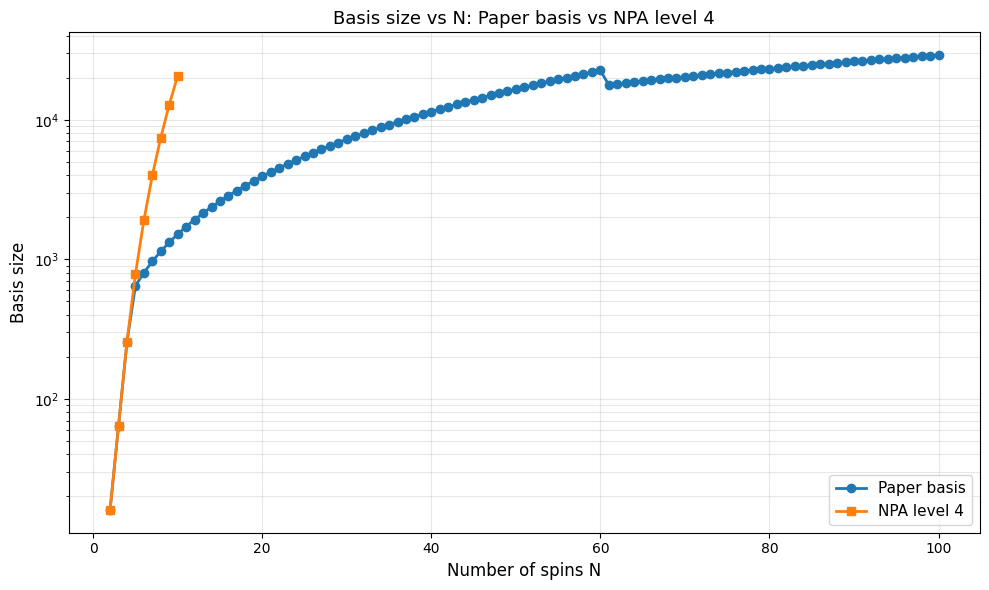

In [17]:

# Plot
plt.figure(figsize=(10, 6))
plt.plot(N_paper, paper_sizes, 'o-', linewidth=2, markersize=6, label='Paper basis')
plt.plot(N_npa4, npa4_sizes, 's-', linewidth=2, markersize=6, label='NPA level 4')
plt.yscale('log')
plt.xlabel('Number of spins N', fontsize=12)
plt.ylabel('Basis size', fontsize=12)
plt.title('Basis size vs N: Paper basis vs NPA level 4', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [9]:
# Print paper basis sizes for N=10,20,...,100
N_values = [6, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(f"{'N':<5} {'Basis Size':<12}")
print("-" * 17)
for N in N_values:
    idx = N - 2  # N_paper starts at 2
    if idx < len(paper_sizes):
        print(f"{N:<5} {paper_sizes[idx]:<12}")

N     Basis Size  
-----------------
6     802         
10    1516        
20    3931        
30    7246        
40    11461       
50    16576       
60    22591       
70    20371       
80    23281       
90    26191       
100   29101       


In [27]:
# Use the forecast from the graph above to estimate runtime for each N
import numpy as np

a = fit_info['a']
b = fit_info['b']

print(f"Forecast equation (power-law): t = {a:.4g} * L^{b:.4g}")
print(f"\nEstimated runtimes:")
print(f"{'N':<5} {'L':<7} {'Time (s)':<12} {'Days':<12} {'Months':<12} {'Years':<12}")
print("-" * 70)

for N in N_values:
    idx = N - 2
    if idx < len(paper_sizes):
        L = paper_sizes[idx]
        t_est = a * (L ** b)
        days = t_est / 86400
        months = days / 30.44  # average month length
        years = days / 365.25
        print(f"{N:<5} {L:<7} {t_est:<12.3e} {days:<12.3e} {months:<12.3e} {years:<12.3e}")

Forecast equation (power-law): t = 1.028e-07 * L^3.856

Estimated runtimes:
N     L       Time (s)     Days         Months       Years       
----------------------------------------------------------------------
10    1516    1.894e+05    2.192e+00    7.200e-02    6.000e-03   
20    3931    7.464e+06    8.639e+01    2.838e+00    2.365e-01   
30    7246    7.891e+07    9.133e+02    3.000e+01    2.500e+00   
40    11461   4.623e+08    5.351e+03    1.758e+02    1.465e+01   
50    16576   1.918e+09    2.220e+04    7.294e+02    6.079e+01   
60    22591   6.330e+09    7.327e+04    2.407e+03    2.006e+02   
70    20371   4.248e+09    4.917e+04    1.615e+03    1.346e+02   
80    23281   7.109e+09    8.228e+04    2.703e+03    2.253e+02   
90    26191   1.120e+10    1.296e+05    4.257e+03    3.548e+02   
100   29101   1.681e+10    1.945e+05    6.390e+03    5.326e+02   


In [5]:
from spins_sdp.sdp import solve_pauli_relaxation
from spins_sdp.basis_builder import generate_heisenberg_paper_basis
from spins_sdp.models import heisenberg_hamiltonian_dict

basis = generate_heisenberg_paper_basis(N=4)

H = heisenberg_hamiltonian_dict(N=4)

val_primal = solve_pauli_relaxation(basis, H, formulation="primal", solver="MOSEK")
print(f"Primal value: {val_primal}")

val_dual   = solve_pauli_relaxation(basis, H, formulation="dual",   solver="MOSEK")
print(f"Dual value:   {val_dual}")

TypeError: solve_pauli_relaxation() got an unexpected keyword argument 'formulation'

In [8]:
from spins_sdp.basis_builder import generate_heisenberg_paper_basis, generate_npa_basis, split_basis_by_signature

N = 10

basis_paper = generate_heisenberg_paper_basis(N=N)
basis_1 = generate_npa_basis(N=N, k=1)
basis_2 = generate_npa_basis(N=N, k=2)

for sig in [(0,0), (1,0), (0,1), (1,1)]:
    paper_sig = split_basis_by_signature(basis_paper)[sig]
    npa1_sig  = split_basis_by_signature(basis_1.words)[sig]
    npa2_sig  = split_basis_by_signature(basis_2.words)[sig]
    print(f"Signature {sig}: Paper basis size = {len(paper_sig)}, NPA k1 size = {len(npa1_sig)}, NPA k2 size = {len(npa2_sig)}")

Signature (0, 0): Paper basis size = 406, NPA k1 size = 1, NPA k2 size = 136
Signature (1, 0): Paper basis size = 370, NPA k1 size = 10, NPA k2 size = 100
Signature (0, 1): Paper basis size = 370, NPA k1 size = 10, NPA k2 size = 100
Signature (1, 1): Paper basis size = 370, NPA k1 size = 10, NPA k2 size = 100


## Symmetry-Enabled SDP Benchmarks for Heisenberg Model

The following cells benchmark SDP performance with different symmetry configurations for the Heisenberg model. **Results are saved as artifacts** so you don't need to re-run the benchmark each time.

### Symmetry Levels (Cumulative)

| Level | Symmetries Enabled | Description |
|-------|-------------------|-------------|
| 0 | None | Baseline (no symmetries) |
| 1 | +Real | Restrict to real moments |
| 2 | +Rotation | Block-diagonalize by Pauli signature |
| 3 | +Sign | Zero out sign-variant moments |
| 4 | +Permutation | Group by X↔Y↔Z relabeling |
| 5 | +Translation | Group by cyclic translation |
| 6 | +Mirror (All) | Full symmetry (default for Heisenberg) |

### Workflow

1. **Run benchmark** (first cell): Computes timing data and saves to `spins_sdp/results/spin_symmetry_benchmark/`
2. **Plot speedup** (second cell): Loads saved data and plots timing vs N for each symmetry level
3. **Plot variable reduction**: Shows how many SDP variables are eliminated by each symmetry
4. **Forecast**: Fits a power-law scaling model and extrapolates to larger N

In [6]:
# Run the symmetry benchmark (saves results as artifact for reuse)

from spins_sdp.scripts import symmetry_benchmark

# Results are saved to spins_sdp/results/spin_symmetry_benchmark/v1/<hash>/
symmetry_benchmark.main([
    "--model", "heisenberg",
    #"--npa-level", "2",
    "--basis", "heisenberg_simple",
    "--boundary", "periodic",
    "--N-min", "2",
    "--N-max", "20",
    "--repeats", "1",
    "--sym-levels", "6",
    "--resume",  # Skip already-computed (N, sym_level) pairs
])

Model: heisenberg, Basis: heisenberg_simple, boundary: periodic
Total jobs: 19, Already done: 0, To compute: 19


Symmetry benchmark: 100%|██████████| 19/19 [23:21<00:00, 73.79s/it, N=20, sym=6] 

Results saved to: /mnt/c/Users/lmatos/Desktop/code/SpinsSDP/spins_sdp/results/spin_symmetry_benchmark/v1/a48deff1bb675f52


0

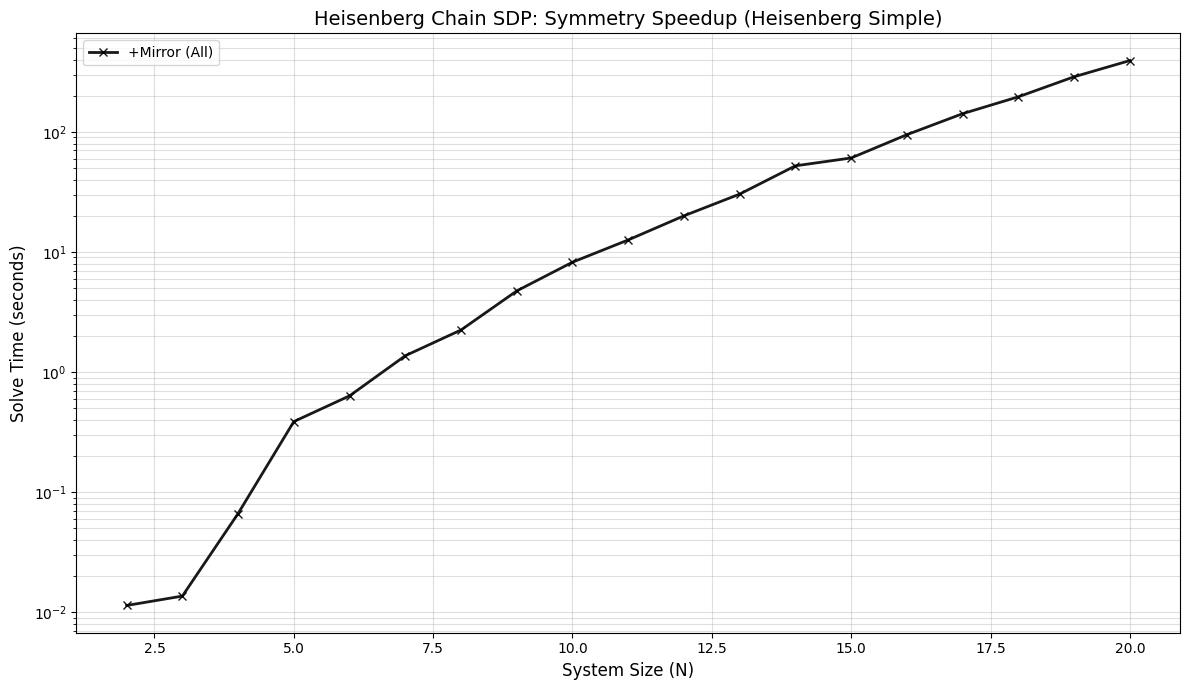

In [7]:
# Plot symmetry speedup from saved artifact (no recomputation needed)
from plots import plot_symmetry_speedup

result = plot_symmetry_speedup(
    model="heisenberg",
    basis="heisenberg_simple",
    boundary="periodic",
    time_column="t_best",  # Use best time from repeats
)

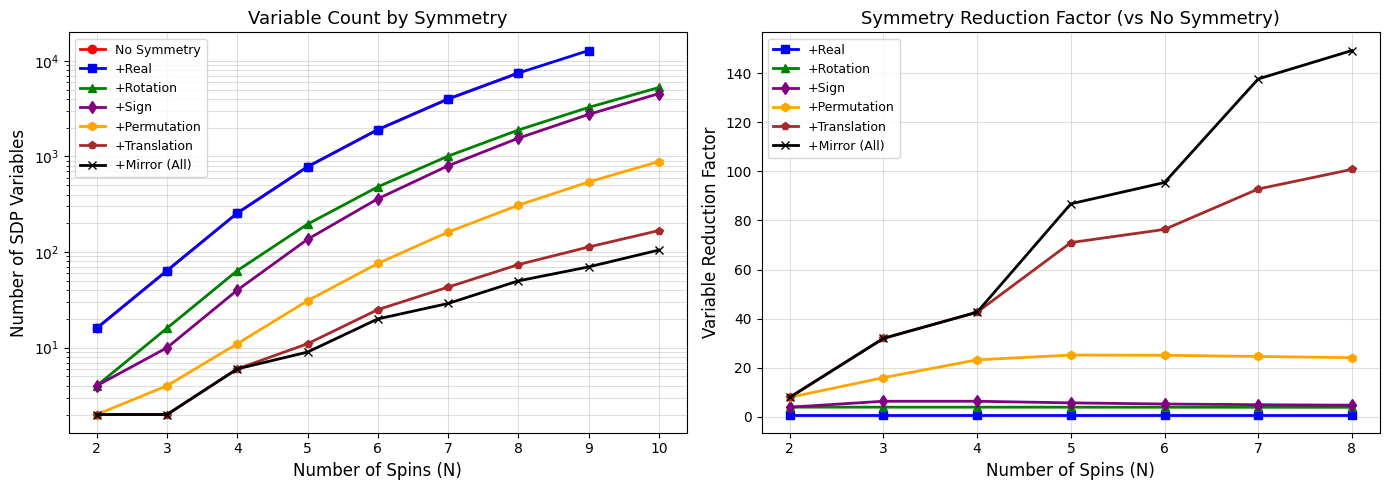

In [6]:
# Plot variable reduction from saved artifact
from plots import plot_symmetry_variable_reduction

result_vars = plot_symmetry_variable_reduction(
    model="heisenberg",
    npa_level=2,
    boundary="periodic",
)

## Runtime Forecasting with Full Symmetry

Now let's fit a power-law scaling model to the timing data with **all symmetries enabled** (level 6) and forecast runtimes for larger system sizes.

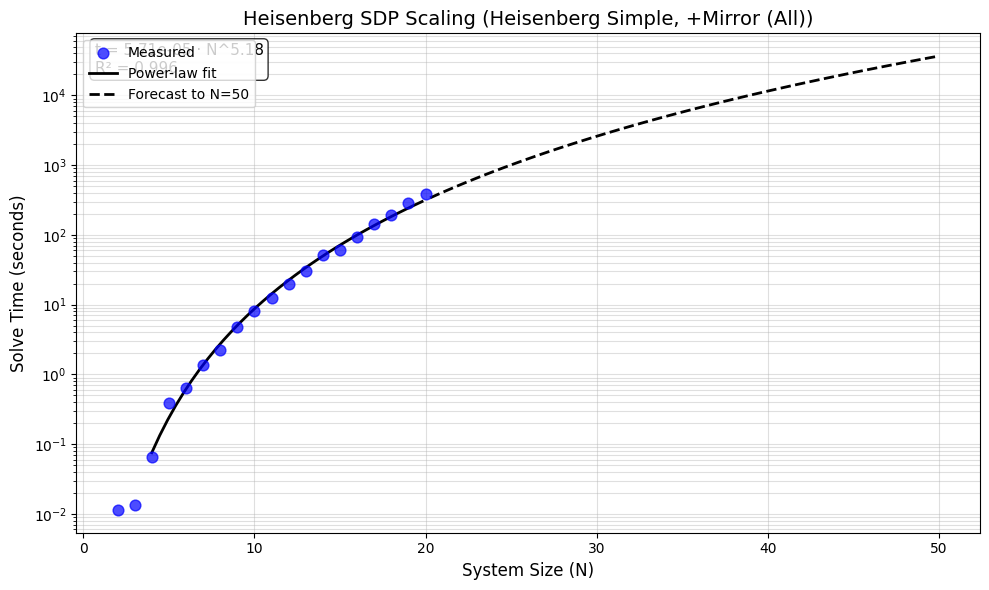


Fit: t = 5.715e-05 · N^5.184 (R² = 0.9956)


In [8]:
# Fit scaling and forecast with all symmetries (level 6)
from plots import plot_symmetry_forecast, fit_symmetry_scaling, print_symmetry_forecast_table

forecast_result = plot_symmetry_forecast(
    model="heisenberg",
    basis="heisenberg_simple",
    boundary="periodic",
    sym_level=6,  # All symmetries
    fit_N_min=4,
    forecast_to_N=50,
    time_column="t_best",
)

# Print the fit equation
fit = forecast_result["fit_info"]
print(f"\nFit: t = {fit['a']:.4g} · N^{fit['b']:.4g} (R² = {fit['r2']:.4f})")

In [ ]:
# Print forecast table for various N values
from plots import print_symmetry_forecast_table

N_targets = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print_symmetry_forecast_table(fit, N_targets)

## Parallel Tempering Optimization Timing

This section plots *wall-clock optimization time* vs number of selected monomials $k$ for a **fixed** system size $N$, using saved artifacts from `spins_sdp.scripts.optimization_sweep` (method `pt`).

Tip: if you’re not sure what PT configs you’ve already run, call `list_optimization_runs(method="pt")` to see available hashes and metadata.

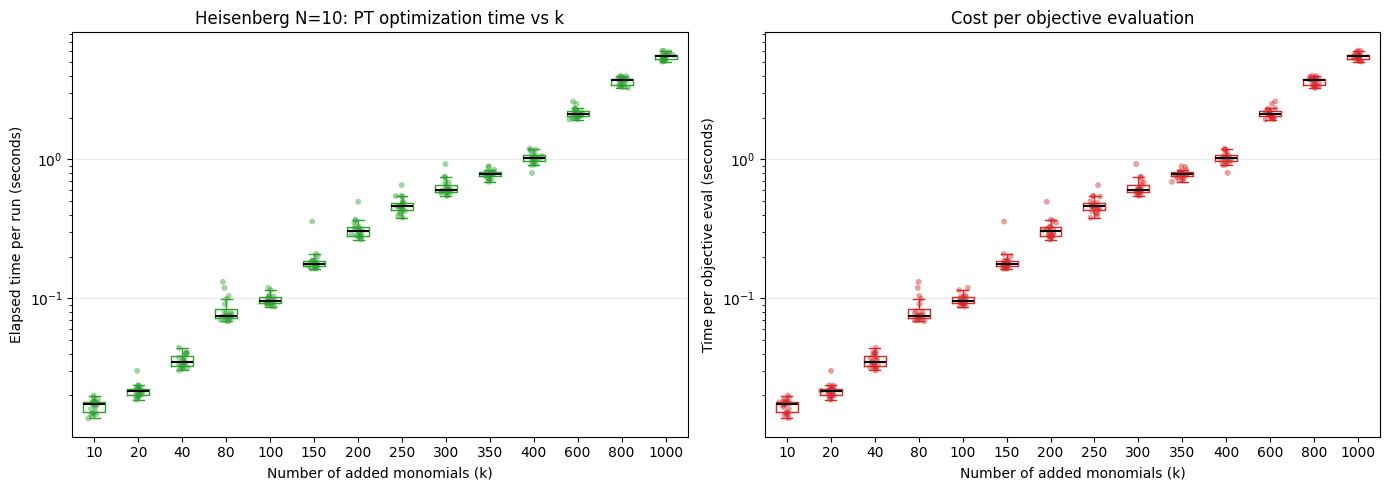

In [7]:
# Plot PT optimization timing vs k from saved artifact
from plots import plot_pt_optimization_timing_by_k, list_optimization_runs

# (Optional) Inspect what PT optimization sweeps exist on disk
# list_optimization_runs(method="pt")

# Choose a configuration that matches the run you generated with:
#   python -m spins_sdp.scripts.optimization_sweep ... --method pt ...
N = 8
pt_params = {
    "num_chains": 8,
    "num_epochs": 30,
    "steps_per_epoch": 50,
    "T_min": 0.1,
    "T_max": 10.0,
}

# result_pt_time = plot_pt_optimization_timing_by_k(
#     model="heisenberg",
#     N=N,
#     boundary="periodic",
#     start_level=1,
#     end_level=2,
#     pt_params=pt_params,
#     show_points=True,
#     logy=False,
#     show=True,
#  )

result_pt_time = plot_pt_optimization_timing_by_k(run_hash="887746421a13f5fd", logy=True)